In [1]:
from IPython.display import HTML

# standard imports
import numpy as np
from scipy import linalg
import matplotlib.pyplot as plt
import math
from math import pi
np.set_printoptions(
    linewidth=120, formatter={
        'float': lambda x: f"{0:8.4g}" if abs(x) < 1e-10 else f"{x:8.4g}"})
np.random.seed(0)
from spatialmath import *
from spatialmath.base import *

### Distance Between Orientations

In [2]:
UnitQuaternion.Rx(pi/2).angdist(UnitQuaternion.Rz(-pi/2))

1.0471975511965976

### Normalization

In [3]:
R = np.eye(3, 3)
np.linalg.det(R) - 1

0.0

In [4]:
for i in range(100):
    R = R @ rpy2r(0.2, 0.3, 0.4)
np.linalg.det(R) - 1    

5.773159728050814e-15

In [5]:
R = trnorm(R)

In [6]:
np.linalg.det(R) - 1

2.220446049250313e-16

In [7]:
q = UnitQuaternion.Rx(pi/2)
q

 0.7071 <<  0.7071,  0.0000,  0.0000 >>


In [8]:
q = q.unit()
q

 0.7071 <<  0.7071,  0.0000,  0.0000 >>


In [9]:
T1 = transl(1, 2, 3) @ trotx(pi/4)
T2 = transl(4, 5, 6) @ trotz(pi/3)
T = T1 @ T2
T

array([[     0.5,   -0.866,        0,        5],
       [  0.6124,   0.3536,  -0.7071,    1.293],
       [  0.6124,   0.3536,   0.7071,    10.78],
       [       0,        0,        0,        1]])

In [10]:
q1 = UnitQuaternion.Rx(pi/2)
q2 = UnitQuaternion.Rz(-pi/2)
q = q1 @ q2
q

 0.5000 <<  0.5000,  0.5000, -0.5000 >>


### More About Twists

In [11]:
S = Twist3.UnitRevolute([1, 0, 0], [0, 0, 0])
S

(0 0 0; 1 0 0)

In [12]:
S.S

array([       0,        0,        0,        1,        0,        0])

In [13]:
S.v

array([       0,        0,        0])

In [14]:
S.w

array([       1,        0,        0])

In [20]:
S.SE3(0.3)

   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         


In [19]:
S.exp(0.3)

   1         0         0         0         
   0         0.9553   -0.2955    0         
   0         0.2955    0.9553    0         
   0         0         0         1         


In [21]:
S2 = S * S
S2

(0 0 0; 2 0 0)

In [22]:
S2.printline(orient="angvec", unit="rad")

t = 0, 0, 0; angvec = (2 | 1, 0, 0)


In [23]:
line = S.line()
line

{ 0 0 0; 1 0 0}

Axes3D(0.125,0.11;0.775x0.77)


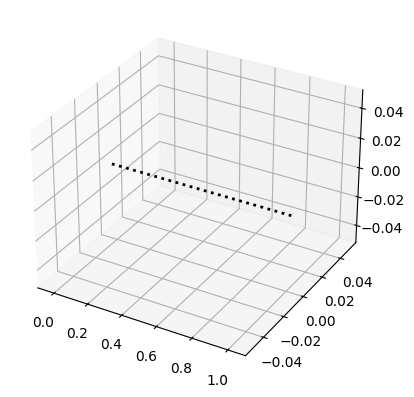

In [29]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

line.plot(ax=ax, color="k", linestyle=":", linewidth=2)

plt.show()

In [30]:
T = transl(1, 2, 3) @ eul2tr(0.3, 0.4, 0.5)
S = Twist3(T)
S

(1.1204 1.6446 3.1778; 0.041006 0.4087 0.78907)

In [31]:
S / S.theta

(1.2594 1.8488 3.5722; 0.046096 0.45943 0.88702)

In [32]:
S.unit()

(0.29881 0.43863 0.84753; 0 0 0)

In [33]:
S.exp(0)

   1         0         0         0         
   0         1         0         0         
   0         0         1         0         
   0         0         0         1         


In [34]:
S.exp(1)

   0.6305   -0.6812    0.372     1         
   0.6969    0.7079    0.1151    2         
  -0.3417    0.1867    0.9211    3         
   0         0         0         1         


In [35]:
S.exp(0.5)

   0.9029   -0.3796    0.2017    0.5447    
   0.3837    0.9232    0.01982   0.9153    
  -0.1937    0.05949   0.9793    1.542     
   0         0         0         1         
